In [12]:
import openml

dataset = openml.datasets.get_dataset(36)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)


print(dataset)
print(f"data shape: {X.shape}")
print(f"name features: {y.nunique()}")
X.head()

OpenML Dataset
Name.........: segment
Version......: 1
Format.......: ARFF
Upload Date..: 2014-04-06 23:22:10
Licence......: Public
Download URL.: https://openml.org/data/v1/download/36/segment.arff
OpenML URL...: https://www.openml.org/d/36
# of features: None
data shape: (2310, 19)
name features: 7


,region-centroid-col,region-centroid-row,region-pixel-count,short-line-density-5,short-line-density-2,vedge-mean,vegde-sd,hedge-mean,hedge-sd,intensity-mean,rawred-mean,rawblue-mean,rawgreen-mean,exred-mean,exblue-mean,exgreen-mean,value-mean,saturation-mean,hue-mean
0,218,178,9,0.111111,0.0,0.833333,0.547722,1.111110,0.544331,59.629600,52.4444,75.22220,51.222200,-21.55560,46.7778,-25.22220,75.22220,0.318996,-2.04055
1,113,130,9,0.000000,0.0,0.277778,0.250924,0.333333,0.365148,0.888889,0.0000,2.55556,0.111111,-2.66667,5.0000,-2.33333,2.55556,1.000000,-2.12325
2,202,41,9,0.000000,0.0,0.944448,0.772202,1.111110,1.025600,123.037000,111.8890,139.77800,117.444000,-33.44440,50.2222,-16.77780,139.77800,0.199347,-2.29992
3,32,173,9,0.000000,0.0,1.722220,1.781590,9.000000,6.749490,43.592600,39.5556,52.88890,38.333300,-12.11110,27.8889,-15.77780,52.88890,0.266914,-1.99886
4,61,197,9,0.000000,0.0,1.444440,1.515350,2.611110,1.925460,49.592600,44.2222,61.55560,43.000000,-16.11110,35.8889,-19.77780,61.55560,0.302925,-2.02227


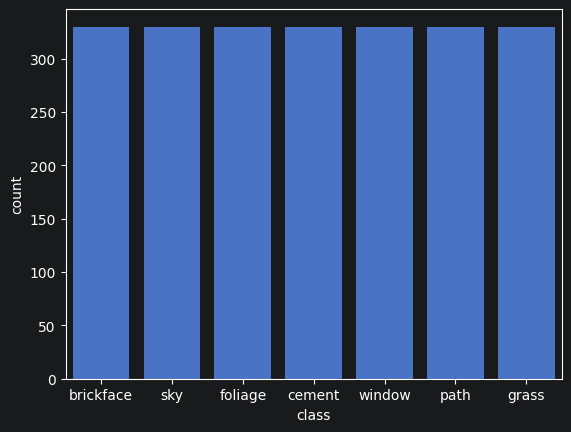

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

class_count = y.value_counts()

sns.barplot(class_count)
plt.show()

# Data standardization and train-test split

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Data is perfectly balanced, but we keep it as good practice
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train

array([[ 1.66606629,  0.88403034,  0.        , ...,  0.60594303,
        -0.4596314 , -0.43904529],
       [-1.18535198,  1.33853181,  0.        , ...,  0.59037174,
        -0.51694206, -0.4666551 ],
       [-1.66286222, -0.56687821,  0.        , ..., -0.8005931 ,
         1.74126732, -0.66232014],
       ...,
       [-0.85791639,  0.35960556,  0.        , ..., -0.90439737,
         0.63308026,  0.2490941 ],
       [-0.76241434, -1.86045933,  0.        , ...,  2.31091692,
        -1.1650672 , -0.63367963],
       [-0.96706159,  0.16731648,  0.        , ..., -0.83952017,
         0.8757352 , -0.44590587]])

# MLP model

In [ ]:
from torch import nn
from typing import Literal

class MLP_classifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, activation:Literal['ReLU', 'Tanh'], input_dim:int=x_train.shape[0], output_dim:int = y_train.shape[1]):
        super(MLP_classifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x


# Optuna for best three models

In [ ]:
import os
import numpy as np

import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader, Subset



DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def _train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    return avg_loss

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss


# Hyperparameters for tunning
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 10
batch_size = 256
lr = 0.01

# Saving Dir
PATH = os.path.join('Models','folds')
os.makedirs(PATH, exist_ok=True)

# Data Preparation
X_trainval_tensor = torch.from_numpy(x_train).float()
y_trainval_tensor = torch.from_numpy(y_train).float()
dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)

N = X_trainval_tensor.shape[0]
idx = np.arange(N)

train_loader = DataLoader(Subset(dataset, idx[:int(0.8*N)]), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(Subset(dataset, idx[int(0.8*N):]), batch_size=batch_size)



def architecture_objective(trial):
    global dataset, DEVICE, num_epochs, batch_size, lr

    n_hidden = trial.suggest_int(1, 16)
    hidden_dim = trial.suggest_int(1, 512)
    activation = trial.suggest_choice(['ReLU', 'Tanh'])



